# Maze Navigation Problem

Implementation of the maze navigation problem from AIMA Exercise 3.2.

## Problem Description

The maze from Exercise 3.2:

```text
 __ __ __ __ __
|  |__|        |
|  |  |__   |  |
|        a  |__|
|  |__|__|__|  |
|__ __ __ __   |
             g
```

**Goal**: Get out of the maze using as few steps as possible.

### Problem Formulation (Part a)

- **State**: Position and orientation of agent in maze
- **Initial State**: Agent at maze center (a) facing north
- **Actions**: turn(n, e, s, w), forward(steps)
- **Transition Model**: 
  - turn() changes agent orientation
  - forward() moves agent forward by specified steps
  - forward() stops at walls
- **Goal Test**: Check if agent is in goal square (g)
- **Path Cost**: Each action costs 1
- **State Space**: 25 cells × 4 orientations = 100 states

## Imports

In [1]:
# Import required modules
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().resolve().parent.parent))

from search4e import Problem, astar_search, path_states, path_actions
from search4e import uniform_cost_search, greedy_bfs, weighted_astar_search
from search4e import breadth_first_search, report
import matplotlib.pyplot as plt

## MazeProblem Class

Implementation follows the GridProblem pattern from search4e.ipynb with these key features:

- **State**: `(x, y)` position tuple (simplified from exercise - no orientation tracking)
- **Actions**: Direction offset tuples `(dx, dy)` for N/E/S/W movement
- **Walls**: Set of blocked transitions `{((x1,y1), (x2,y2)), ...}` for O(1) lookup
- **Heuristic**: Manhattan distance (appropriate for 4-directional grid movement)
- **Action Cost**: Uniform cost of 1 per step

In [2]:
class MazeProblem(Problem):
    """
    Navigation problem in a maze with walls.
    Simplified version using position-only state (no orientation).
    
    State: (x, y) coordinate tuple
    Actions: Movement direction offsets (dx, dy)
    Walls: Set of blocked transitions between adjacent cells
    """
    
    # 4-directional movement: North, East, South, West
    directions = [(0, -1), (1, 0), (0, 1), (-1, 0)]
    direction_names = {(0, -1): 'N', (1, 0): 'E', (0, 1): 'S', (-1, 0): 'W'}
    
    def __init__(self, initial, goal, walls, grid_size=(5, 5), **kwds):
        """
        Args:
            initial: (x, y) start position
            goal: (x, y) goal position
            walls: set of blocked transition tuples ((x1,y1), (x2,y2))
            grid_size: (width, height) of the maze grid
        """
        Problem.__init__(self, initial=initial, goal=goal, **kwds)
        self.walls = walls
        self.grid_size = grid_size
    
    def actions(self, state):
        """
        Return valid movement directions from current state.
        Checks both grid boundaries and wall transitions.
        
        Returns:
            List of (dx, dy) offset tuples
        """
        x, y = state
        valid_actions = []
        
        for dx, dy in self.directions:
            new_x, new_y = x + dx, y + dy
            new_state = (new_x, new_y)
            
            # Check grid boundaries
            if not (0 <= new_x < self.grid_size[0] and 0 <= new_y < self.grid_size[1]):
                continue
            
            # Walls are bidirectional, so check both direction blocks
            if (state, new_state) in self.walls or (new_state, state) in self.walls:
                continue
            
            valid_actions.append((dx, dy))
        
        return valid_actions
    
    def result(self, state, action):
        """
        Apply movement action to state.
        
        Args:
            state: current (x, y) position
            action: (dx, dy) movement offset
        
        Returns:
            New (x, y) position
        """
        x, y = state
        dx, dy = action
        return (x + dx, y + dy)
    
    def action_cost(self, s, a, s1):
        """Each step costs 1."""
        return 1
    
    def h(self, node):
        """
        Manhattan distance heuristic (admissible for 4-directional grid).
        """
        x1, y1 = node.state
        x2, y2 = self.goal
        return abs(x1 - x2) + abs(y1 - y2)
    
    def is_goal(self, state):
        """Check if current state is the goal."""
        return state == self.goal

## Exercise 3.2 Maze Definition

Encoding the maze from Exercise 3.2:

```text
 __ __ __ __ __
|  |__|        |
|  |  |__   |  |
|        a  |__|
|  |__|__|__|  |
|__ __ __ __   |
             g
```

Grid coordinates (origin at top-left):
- Agent start 'a': (2, 2) - center of maze
- Goal 'g': (4, 4) - bottom right exit
- Grid size: 5×5

In [3]:
# Define the maze walls as blocked transitions
# Coordinate system: (x, y) where x=column (0-4 left to right), y=row (0-4 top to bottom)

maze_walls = set()

# Row 0 (top): walls create the top boundary pattern
maze_walls.update([
    ((1, 0), (1, 1)),  # Vertical wall between columns 1-2
])

# Row 1: walls in middle section
maze_walls.update([
    ((1, 1), (1, 2)),  # Vertical wall continues down
    ((1, 1), (2, 1)),  # Horizontal wall to the right
    ((2, 1), (2, 2)),  # Vertical wall down from (2,1)
])

# Row 2: wall segments creating chambers
maze_walls.update([
    ((2, 2), (2, 3)),  # Vertical wall continues
    ((3, 2), (4, 2)),  # Horizontal wall on right side
])

# Row 3: complex wall pattern
maze_walls.update([
    ((1, 3), (1, 4)),  # Vertical wall on left
    ((1, 3), (2, 3)),  # Horizontal wall segment
    ((2, 3), (2, 4)),  # Vertical wall down
    ((2, 3), (3, 3)),  # Horizontal wall segment
    ((3, 3), (3, 4)),  # Vertical wall down
    ((3, 3), (4, 3)),  # Horizontal wall to right edge
])

# Row 4 (bottom): mostly open except for walls
maze_walls.update([
    # Bottom row has opening at (4,4) for goal
])

# Outer boundary walls (implicit but we can check in actions method via grid_size)

# Define problem instance
maze_start = (2, 2)  # Agent 'a' position
maze_goal = (4, 4)   # Goal 'g' position

maze_problem = MazeProblem(
    initial=maze_start,
    goal=maze_goal,
    walls=maze_walls,
    grid_size=(5, 5)
)

print("Maze problem created!")
print(f"Start: {maze_problem.initial}")
print(f"Goal: {maze_problem.goal}")
print(f"Grid size: {maze_problem.grid_size}")
print(f"Number of wall segments: {len(maze_problem.walls)}")

Maze problem created!
Start: (2, 2)
Goal: (4, 4)
Grid size: (5, 5)
Number of wall segments: 12


## Test Available Actions

Check what moves are possible from the starting position.

In [4]:
# Test actions from start position
start_actions = maze_problem.actions(maze_start)

print(f"From start position {maze_start}, available moves:")
for action in start_actions:
    direction_name = maze_problem.direction_names[action]
    new_pos = maze_problem.result(maze_start, action)
    print(f"  {direction_name} {action} -> {new_pos}")

From start position (2, 2), available moves:
  E (1, 0) -> (3, 2)
  W (-1, 0) -> (1, 2)


## Solve Maze with A* Search

In [5]:
# Solve the maze problem with A* search
maze_solution = astar_search(maze_problem)

if maze_solution:
    print("Solution found!")
    print(f"\nPath from {maze_start} to {maze_goal}:")
    
    # Get the path
    path = path_states(maze_solution)
    actions = path_actions(maze_solution)
    
    # Display step-by-step solution
    for i, state in enumerate(path):
        if i == 0:
            print(f"  Start: {state}")
        elif i < len(path):
            action = actions[i-1]
            direction = maze_problem.direction_names.get(action, action)
            print(f"  Step {i}: {path[i-1]} --{direction}--> {state}")
    
    print(f"\nTotal path cost: {maze_solution.path_cost}")
    print(f"Number of steps: {len(actions)}")
else:
    print("No solution found!")

Solution found!

Path from (2, 2) to (4, 4):
  Start: (2, 2)
  Step 1: (2, 2) --E--> (3, 2)
  Step 2: (3, 2) --N--> (3, 1)
  Step 3: (3, 1) --E--> (4, 1)
  Step 4: (4, 1) --S--> (4, 2)
  Step 5: (4, 2) --S--> (4, 3)
  Step 6: (4, 3) --S--> (4, 4)

Total path cost: 6
Number of steps: 6


## Compare Search Algorithms on Maze

Test multiple search algorithms to compare their performance on the maze problem.

In [7]:
# Test multiple search algorithms on the maze problem
maze_algorithms = [
    ("A* Search", astar_search),
    ("Uniform Cost Search", uniform_cost_search),
    ("Greedy Best-First Search", greedy_bfs),
    ("Breadth-First Search", breadth_first_search),
    ("Weighted A* (w=1.5)", lambda p: weighted_astar_search(p, weight=1.5)),
]

print("Comparing Search Algorithms on Maze Problem")
print("=" * 80)

maze_results = {}

for name, algorithm in maze_algorithms:
    solution = algorithm(maze_problem)
    
    if solution and solution.path_cost < float('inf'):
        path = path_states(solution)
        actions = path_actions(solution)
        
        print(f"\n{name}:")
        print(f"  Path cost: {solution.path_cost}")
        print(f"  Steps: {len(actions)}")
        print(f"  Path: {' -> '.join(str(s) for s in path)}")
        
        maze_results[name] = solution
    else:
        print(f"\n{name}: No solution found")
        maze_results[name] = None

print("\n" + "=" * 80)

Comparing Search Algorithms on Maze Problem

A* Search:
  Path cost: 6
  Steps: 6
  Path: (2, 2) -> (3, 2) -> (3, 1) -> (4, 1) -> (4, 2) -> (4, 3) -> (4, 4)

Uniform Cost Search:
  Path cost: 6
  Steps: 6
  Path: (2, 2) -> (3, 2) -> (3, 1) -> (4, 1) -> (4, 2) -> (4, 3) -> (4, 4)

Greedy Best-First Search:
  Path cost: 6
  Steps: 6
  Path: (2, 2) -> (3, 2) -> (3, 1) -> (4, 1) -> (4, 2) -> (4, 3) -> (4, 4)

Breadth-First Search:
  Path cost: 6
  Steps: 6
  Path: (2, 2) -> (3, 2) -> (3, 1) -> (4, 1) -> (4, 2) -> (4, 3) -> (4, 4)

Weighted A* (w=1.5):
  Path cost: 6
  Steps: 6
  Path: (2, 2) -> (3, 2) -> (3, 1) -> (4, 1) -> (4, 2) -> (4, 3) -> (4, 4)



## Detailed Performance Report

Using the `report()` function to get comprehensive statistics.

In [8]:
# Detailed performance comparison using report()
print("\nDetailed Performance Report: Maze Problem")
print("=" * 100)

maze_searchers = [
    astar_search,
    uniform_cost_search,
    greedy_bfs,
    breadth_first_search,
    lambda p: weighted_astar_search(p, weight=1.5),
]

# Name the lambda function
maze_searchers[4].__name__ = "weighted_astar_1.5"

# Run the report
report(maze_searchers, [maze_problem], verbose=True)


Detailed Performance Report: Maze Problem
astar_search:
       22 nodes |       10 goal |    6 cost |      15 actions | MazeProblem((2, 2), (4, 4))
       22 nodes |       10 goal |    6 cost |      15 actions | TOTAL

uniform_cost_search:
       50 nodes |       22 goal |    6 cost |      27 actions | MazeProblem((2, 2), (4, 4))
       50 nodes |       22 goal |    6 cost |      27 actions | TOTAL

greedy_bfs:
       17 nodes |        8 goal |    6 cost |      13 actions | MazeProblem((2, 2), (4, 4))
       17 nodes |        8 goal |    6 cost |      13 actions | TOTAL

breadth_first_search:
       48 nodes |       49 goal |    6 cost |      26 actions | MazeProblem((2, 2), (4, 4))
       48 nodes |       49 goal |    6 cost |      26 actions | TOTAL

weighted_astar_1.5:
       17 nodes |        8 goal |    6 cost |      13 actions | MazeProblem((2, 2), (4, 4))
       17 nodes |        8 goal |    6 cost |      13 actions | TOTAL



## Visual Comparison: Problem vs Solution

Side-by-side view of the maze structure and the found solution path.

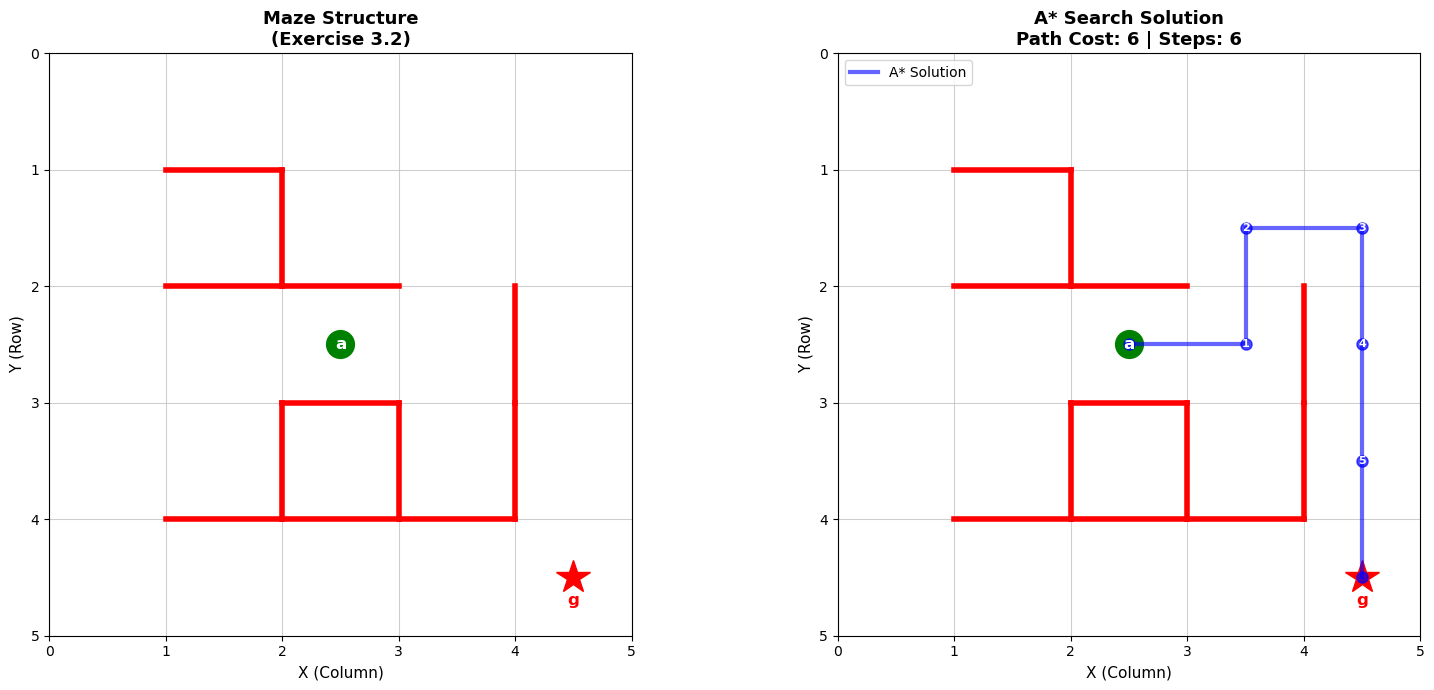

In [11]:
def visualize_maze(problem, solution=None, figsize=(16, 7)):
    """
    Visualize maze with side-by-side comparison of problem structure and solution.
    
    Args:
        problem: MazeProblem instance
        solution: solution node from search (optional)
        figsize: figure size tuple
    """
    # Create side-by-side layout
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    width, height = problem.grid_size
    
    # Draw both subplots
    for ax in [ax1, ax2]:
        # Draw grid cells
        for x in range(width):
            for y in range(height):
                rect = plt.Rectangle((x, y), 1, 1, fill=True, 
                                    facecolor='white', edgecolor='lightgray', linewidth=0.5)
                ax.add_patch(rect)
        
        # Draw walls
        for (x1, y1), (x2, y2) in problem.walls:
            if x1 == x2:  # Vertical wall
                if y2 > y1:
                    ax.plot([x1, x1+1], [y2, y2], 'r-', linewidth=4)
                else:
                    ax.plot([x1, x1+1], [y1, y1], 'r-', linewidth=4)
            else:  # Horizontal wall
                if x2 > x1:
                    ax.plot([x2, x2], [y1, y1+1], 'r-', linewidth=4)
                else:
                    ax.plot([x1, x1], [y1, y1+1], 'r-', linewidth=4)
        
        # Draw start and goal
        start_x, start_y = problem.initial
        goal_x, goal_y = problem.goal
        ax.plot(start_x + 0.5, start_y + 0.5, 'go', markersize=20)
        ax.text(start_x + 0.5, start_y + 0.5, 'a', ha='center', va='center', 
                fontsize=12, fontweight='bold', color='white')
        ax.plot(goal_x + 0.5, goal_y + 0.5, 'r*', markersize=25)
        ax.text(goal_x + 0.5, goal_y + 0.7, 'g', ha='center', va='center', 
                fontsize=12, fontweight='bold', color='red')
        
        ax.set_xlim(0, width)
        ax.set_ylim(0, height)
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.set_xlabel('X (Column)', fontsize=11)
        ax.set_ylabel('Y (Row)', fontsize=11)
        ax.set_xticks(range(width + 1))
        ax.set_yticks(range(height + 1))
        ax.grid(True, alpha=0.3)
    
    # Left plot: Problem structure only
    ax1.set_title('Maze Structure\n(Exercise 3.2)', fontsize=13, fontweight='bold')
    
    # Right plot: Add solution path if provided
    if solution:
        path = path_states(solution)
        path_x = [state[0] + 0.5 for state in path]
        path_y = [state[1] + 0.5 for state in path]
        ax2.plot(path_x, path_y, 'b-', linewidth=3, alpha=0.6, label='A* Solution')
        ax2.plot(path_x, path_y, 'bo', markersize=8, alpha=0.7)
        
        # Add step numbers
        for i, (x, y) in enumerate(zip(path_x, path_y)):
            if i > 0 and i < len(path) - 1:
                ax2.text(x, y, str(i), ha='center', va='center', 
                       fontsize=8, color='white', fontweight='bold')
        
        ax2.set_title(f'A* Search Solution\nPath Cost: {solution.path_cost:.0f} | Steps: {len(path)-1}', 
                      fontsize=13, fontweight='bold')
        ax2.legend(loc='upper left', fontsize=10)
    else:
        ax2.set_title('No Solution', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Visualize the maze and solution
visualize_maze(maze_problem, maze_solution)